<a href="https://colab.research.google.com/github/SaiPranathi16/envision-ai-interior-redesign/blob/main/notebooks/Week1_Setup_StructureExtraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Envision — Week 1: Setup + Module 1 (Structure Extraction)

**Before running:** In Colab, go to `Runtime > Change runtime type` and select **T4 GPU**, then `Save`.

This notebook covers:
1. Mounting Google Drive (so your work survives session disconnects)
2. Installing required libraries
3. Uploading a sample room photo
4. Extracting room structure two ways: Canny edge detection and SegFormer segmentation

Everything here uses pretrained models — no training required for this module.

## 1. Mount Google Drive
Always save your work here — free-tier Colab sessions can disconnect without warning.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Envision_Project'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/sample_images', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/outputs', exist_ok=True)
print('Project folder ready at:', PROJECT_DIR)

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/Envision_Project


## 2. Install required libraries
This may take a few minutes the first time.

In [2]:
!pip install -q diffusers transformers accelerate opencv-python-headless ultralytics controlnet-aux

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 25.6 MB/s eta 0:00:00


## 3. Upload a sample room photo
Run this cell and choose a photo from your computer. It will also save a copy to your Drive project folder for reuse later.

In [3]:
from google.colab import files
import shutil

uploaded = files.upload()
sample_filename = list(uploaded.keys())[0]
shutil.copy(sample_filename, f'{PROJECT_DIR}/sample_images/{sample_filename}')
print('Saved to Drive:', f'{PROJECT_DIR}/sample_images/{sample_filename}')

Saving Room.jpg to Room.jpg
Saved to Drive: /content/drive/MyDrive/Envision_Project/sample_images/Room.jpg


## 4a. Structure extraction — Canny edge detection
Fast, no model download needed. Good baseline for ControlNet conditioning.

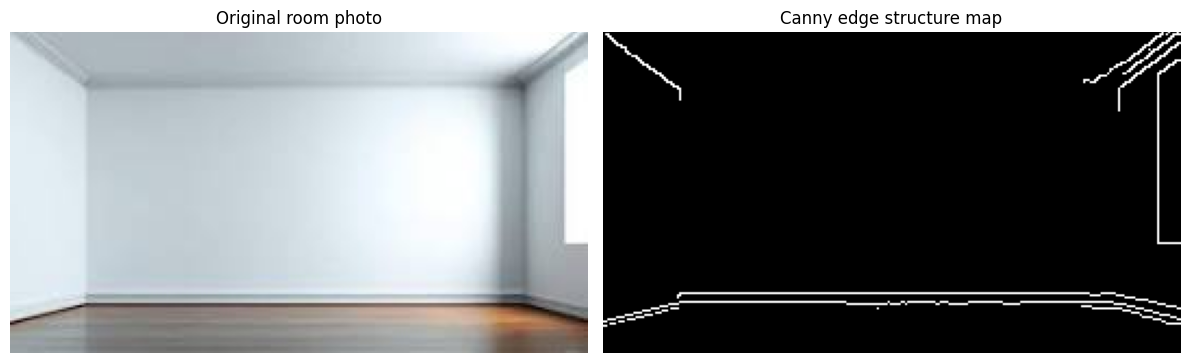

Saved structure map to Drive.


In [4]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

image = cv2.imread(sample_filename)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, threshold1=100, threshold2=200)
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image_rgb); ax[0].set_title('Original room photo'); ax[0].axis('off')
ax[1].imshow(edges_rgb); ax[1].set_title('Canny edge structure map'); ax[1].axis('off')
plt.tight_layout()
plt.show()

Image.fromarray(edges_rgb).save(f'{PROJECT_DIR}/outputs/canny_structure.png')
print('Saved structure map to Drive.')

## 4b. Structure extraction — SegFormer semantic segmentation
Slower (downloads a pretrained model, first run only), but gives you labeled regions (wall, floor, ceiling, furniture) instead of just edges. Useful later for the furniture-detection and click-to-edit modules.

Using device: cuda


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

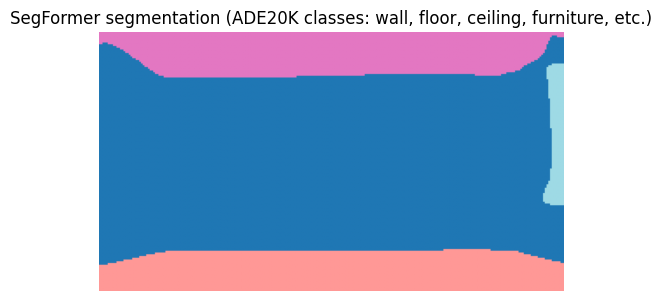

Saved segmentation map to Drive.


In [5]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

processor = SegformerImageProcessor.from_pretrained('nvidia/segformer-b0-finetuned-ade-512-512')
seg_model = SegformerForSemanticSegmentation.from_pretrained('nvidia/segformer-b0-finetuned-ade-512-512').to(device)

pil_image = Image.open(sample_filename).convert('RGB')
inputs = processor(images=pil_image, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = seg_model(**inputs)

logits = outputs.logits
upsampled = torch.nn.functional.interpolate(
    logits, size=pil_image.size[::-1], mode='bilinear', align_corners=False
)
seg_map = upsampled.argmax(dim=1)[0].cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(seg_map, cmap='tab20')
plt.title('SegFormer segmentation (ADE20K classes: wall, floor, ceiling, furniture, etc.)')
plt.axis('off')
plt.show()

np.save(f'{PROJECT_DIR}/outputs/segmentation_map.npy', seg_map)
print('Saved segmentation map to Drive.')

## What's next (Week 2)
- Load YOLOv8 and run furniture detection on this same sample photo
- Start wiring the Canny/segmentation output into ControlNet as the conditioning input

**Reminder:** everything you generate is already saving to your Drive project folder, so you can pick this up in a fresh Colab session without losing work.